# Customer Sales Analysis Dashboard

##### Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Lead DataSheet

df = pd.read_csv('customer_sales_data.csv')

print(df.head())



  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0       C1001    Male   52  South         Clothing                9   
1       C1002  Female   52   West          Grocery                7   
2       C1003    Male   50  North         Clothing                4   
3       C1004    Male   22   West         Clothing               10   
4       C1005    Male   59   West         Clothing                5   

   Price_Per_Unit Purchase_Date  Total_Amount  
0             799    2026-01-01          7191  
1             249    2026-01-02          1743  
2            1299    2026-01-03          5196  
3             399    2026-01-04          3990  
4              99    2026-01-05           495  


In [6]:
# Basic Information

print(df.columns)

print(df.dtypes)

print(df.shape)

Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
Customer_ID           str
Gender                str
Age                 int64
Region                str
Product_Category      str
Units_Purchased     int64
Price_Per_Unit      int64
Purchase_Date         str
Total_Amount        int64
dtype: object
(150, 9)


In [8]:
#convert order_date to datetime

df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

print(df.dtypes)

Customer_ID                    str
Gender                         str
Age                          int64
Region                         str
Product_Category               str
Units_Purchased              int64
Price_Per_Unit               int64
Purchase_Date       datetime64[us]
Total_Amount                 int64
dtype: object


In [9]:
# Numpy Calculation

# Average total amount

average_total = np.mean(df['Total_Amount'])

# Average Item Ordered

average_ordered = np.mean(df['Units_Purchased'])

# Highest Order amount

maximum_order = np.max(df['Total_Amount'])

# Lowest Order amount

minimum_order = np.min(df['Total_Amount'])

print("Numpy Calculation")

print("Average Total Amount :" , average_total)

print("Average items ordered : " , average_ordered)

print("Highest Order amount :" , maximum_order)

print("Lowest Order amount :" , minimum_order)

Numpy Calculation
Average Total Amount : 3077.8733333333334
Average items ordered :  5.793333333333333
Highest Order amount : 14990
Lowest Order amount : 99


In [ ]:
# Group Total Sales by order

Gender_sales = df.groupby("Gender")["Total_Amount"].sum()

print(Gender_sales)

region_sales = df.groupby("Region")["Total_Amount"].sum()

print(region_sales)

category_sales = df.groupby("Product_Category")["Total_Amount"].sum()

print(category_sales)

weekly_sales = df.groupby(
    df["Purchase_Date"].dt.to_period("W")
)["Total_Amount"].sum()

print(weekly_sales)

Gender
Female    255791
Male      205890
Name: Total_Amount, dtype: int64
Region
East      95185
North    115682
South    105350
West     145464
Name: Total_Amount, dtype: int64
Product_Category
Beauty            105079
Clothing          137889
Electronics        85766
Grocery            52126
Home & Kitchen     80821
Name: Total_Amount, dtype: int64
Purchase_Date
2025-12-29/2026-01-04    18120
2026-01-05/2026-01-11    13817
2026-01-12/2026-01-18     8563
2026-01-19/2026-01-25    12829
2026-01-26/2026-02-01    11371
2026-02-02/2026-02-08    24114
2026-02-09/2026-02-15    18326
2026-02-16/2026-02-22    11468
2026-02-23/2026-03-01    11270
2026-03-02/2026-03-08    10266
2026-03-09/2026-03-15    26552
2026-03-16/2026-03-22     9014
2026-03-23/2026-03-29    27066
2026-03-30/2026-04-05    18459
2026-04-06/2026-04-12    22322
2026-04-13/2026-04-19    18469
2026-04-20/2026-04-26    29764
2026-04-27/2026-05-03     4475
2026-05-04/2026-05-10    23211
2026-05-11/2026-05-17    19869
2026-05-18/20

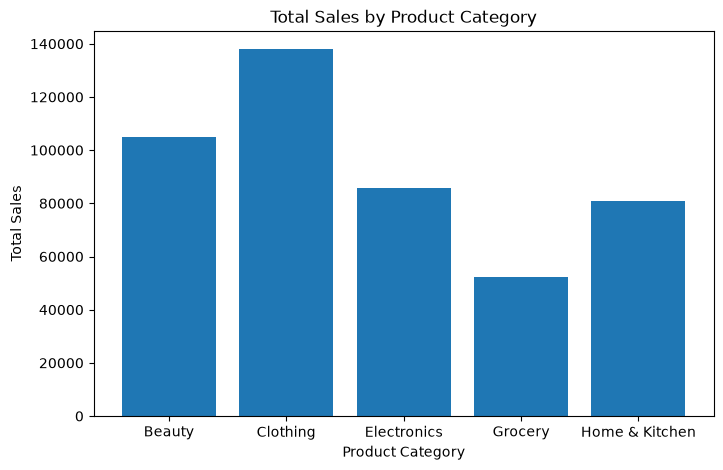

In [ ]:
# Visulization

# Bar chart 

plt.figure(figsize=(8, 5))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.show()